# Customer Segmentation with K-Means Clustering

## Business Context
Retail and e-commerce companies segment customers to personalize marketing, improve retention, and optimize resource allocation. This project applies K-Means clustering on RFM (Recency-Frequency-Monetary) metrics.

**Key objectives:**
- Standardize features for distance-based clustering
- Determine optimal K with elbow method and silhouette analysis
- Interpret and visualize customer segments


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import platform
file_path = '../datasets/Supermarket-customers.csv'

df = pd.read_csv(file_path, encoding='gbk')
df.columns = df.columns.str.strip()
print(f"读取到的列名: {df.columns.tolist()}")


df.set_index('顾客ID', inplace=True)
df.index.name = 'user_ID' # 将索引名字显式改为 user_ID


print("\n[原始数据前5行]: ")
print(df.head())

print("\n" + "-" * 30)
print("正在进行数据标准化 (Z-Score)...")


# 保存原始列名，方便后续还原显示
original_feature_names = df.columns.tolist()
    
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
    
# 转为 DataFrame 格式方便操作
df_scaled = pd.DataFrame(data_scaled, columns=original_feature_names, index=df.index)
print("\n[标准化后的数据前5行]:")
print(df_scaled.head())

print("-" * 30)
print(f"数据预处理完成。\n原始数据维度: {df.shape}\n标准化数据维度: {df_scaled.shape}")

读取到的列名: ['顾客ID', '近期购买时间间隔', '购买频率', '购买金额']

[原始数据前5行]: 
         近期购买时间间隔  购买频率  购买金额
user_ID                      
1000            3     1   619
1001            2     5  2183
1002            5     2   750
1004            3     2   433
1006           10     1   655

------------------------------
正在进行数据标准化 (Z-Score)...

[标准化后的数据前5行]:
         近期购买时间间隔      购买频率      购买金额
user_ID                              
1000    -1.297669 -0.624530 -0.406928
1001    -1.416677  1.900509  1.367580
1002    -1.059653  0.006730 -0.258296
1004    -1.297669  0.006730 -0.617963
1006    -0.464613 -0.624530 -0.366083
------------------------------
数据预处理完成。
原始数据维度: (469, 3)
标准化数据维度: (469, 3)



开始计算不同 K 值的聚类误差 (SSE)...
k=1: SSE=1407.00
k=2: SSE=538.82
k=3: SSE=356.08
k=4: SSE=261.92
k=5: SSE=206.45
k=6: SSE=172.51
k=7: SSE=148.05
k=8: SSE=124.03
k=9: SSE=113.73


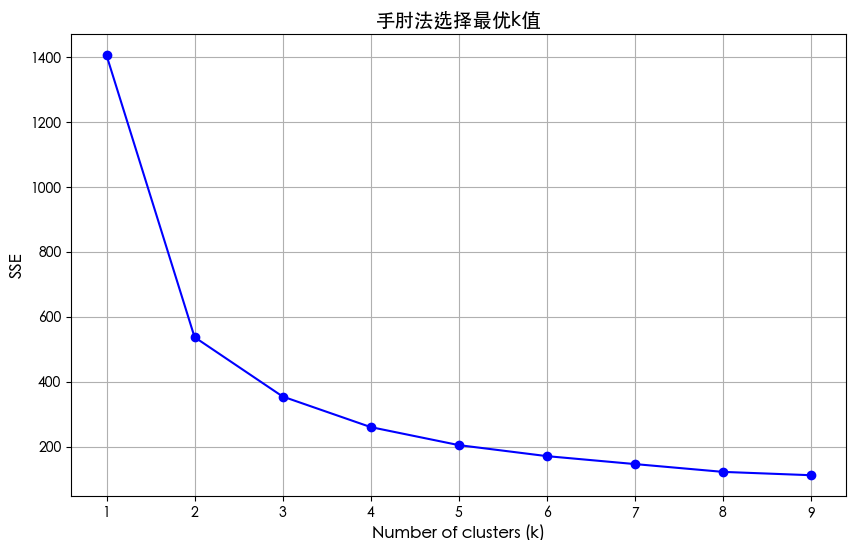

In [10]:
# 手肘法计算

# 设置matplotlib显示中文和负号 (沿用你的设置)
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决保存图像时负号'-'

print("\n开始计算不同 K 值的聚类误差 (SSE)...")

sse_list = []  # 用于存储每次聚类的误差平方和
k_range = range(1, 10)  # 尝试 k=1 到 k=9

for k in k_range:
    # 构建 K-Means 模型
    # random_state=42 保证每次运行结果一致
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    # inertia_ 属性就是 SSE (样本到最近聚类中心的距离平方和)
    sse_list.append(kmeans.inertia_)
    print(f"k={k}: SSE={kmeans.inertia_:.2f}")

# 绘制手肘图
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse_list, marker='o', linestyle='-', color='b')

plt.title('手肘法选择最优k值', fontsize=14)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.xticks(k_range)  # 确保x轴显示所有k值
plt.grid(True)

plt.show()

In [24]:
print("\n=== 聚类结果统计表 ===")
counts = df['Cluster_Label'].value_counts().sort_index()
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
features = df.columns[:-1]

result_df = pd.DataFrame(centers_original, columns=features)
result_df.index.name = '类别'
result_df['人数'] = counts.values
result_df['占比(%)'] = (result_df['人数'] / result_df['人数'].sum() * 100).round(2)

# 调整列顺序并打印
cols = ['人数', '占比(%)'] + list(features)
print(result_df[cols].round(2))


=== 聚类结果统计表 ===
     人数  占比(%)  近期购买时间间隔  购买频率     购买金额
类别                                     
0    96  20.47      3.59  4.70  2414.93
1   169  36.03     10.04  1.51   704.17
2   204  43.50     21.96  1.11   527.85


In [26]:
# ==========================================
# 内置绘图函数 (解决导入报错问题)
# ==========================================
def plot_radar_chart(kmeans_model, columns):
    """
    内置的雷达图绘制函数，无需依赖外部文件
    """
    # 1. 设置字体 (解决中文乱码)
    system_name = platform.system()
    if system_name == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
    else:  # Windows
        plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
    
    plt.rcParams['axes.unicode_minus'] = False
    plt.style.use('ggplot')

    # 2. 准备角度
    N = len(columns)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    # 闭合角度
    angles = np.concatenate((angles, [angles[0]]))

    # 3. 准备绘图
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1, polar=True)

    # 4. 设置标签
    feature_labels = list(columns) + [columns[0]]
    ax.set_thetagrids(angles * 180 / np.pi, feature_labels, fontsize=12)

    # 5. 设置范围
    centers = kmeans_model.cluster_centers_
    ax.set_ylim(centers.min() - 0.5, centers.max() + 0.5)

    # 6. 循环绘制每一类
    # 定义样式
    line_styles = ['-', '-', '-', '-']
    colors = ['r', 'b', 'g', 'orange']
    markers = ['o', 's', '^', 'D']

    print(f"\n正在绘制 {len(centers)} 个类别的雷达图...")
    
    for i in range(len(centers)):
        values = centers[i]
        # 闭合数据
        values = np.concatenate((values, [values[0]]))
        
        # 绘图
        ax.plot(angles, values, linestyle=line_styles[i%4], color=colors[i%4], 
                linewidth=2, label=f'类别 {i}', marker=markers[i%4])
        ax.fill(angles, values, color=colors[i%4], alpha=0.1)

    plt.title('顾客群体价值分布雷达图 (标准化数值)', fontsize=15, pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    plt.grid(True)
    plt.show()


=== 生成雷达图 ===

正在绘制 3 个类别的雷达图...


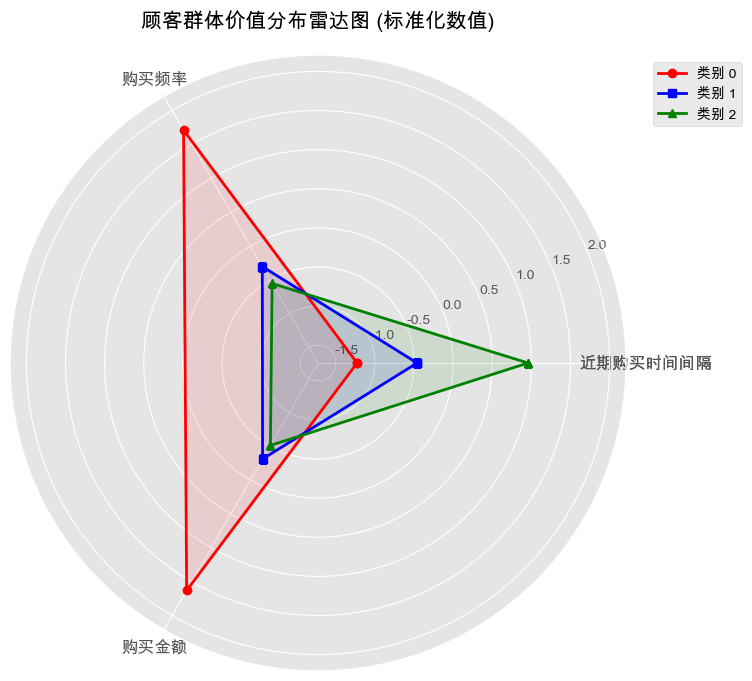

In [28]:
# 5. 绘制雷达图
print("\n=== 生成雷达图 ===")
# 直接调用上面定义的函数，不再需要 radar_map.plot
plot_radar_chart(kmeans, features)

## 1. 核心高价值客户 (VIP)

    图表特征：覆盖面积最大的那个三角形。它在 “购买金额” 和 “购买频率” 两个轴上拉得最长（数值最大），而在 “时间间隔” 轴上数值很小。

    价值定义：他们是超市的金主。买得最贵、来得最勤、且最近刚来过。

    策略：维系与防流失。提供 VIP 专属通道、生日礼、积分加倍，让他们感受到尊贵感。

## 2. 高风险流失客户 (流失)

    图表特征：最突出的特点是有一个角指向 “近期购买时间间隔” 且拉得特别长（数值极大），但金额和频率都缩在中心。

    价值定义：这部分人已经很久没来了，属于沉睡或已流失状态，贡献度极低。

    策略：挽留激活。发送“老客回归”短信或赠送无门槛礼品试探一次，若无反应则停止投入。

## 3. 一般价值客户 (普通)

    图表特征：整体缩在雷达图中心，形成一个较小的闭环。金额、频率都不高，但时间间隔也不长（说明还是活跃的）。

    价值定义：这是人数最多的大众客群。偶尔来买点日用品，客单价低，是超市的基础流量。

    策略：大众促销。维持正常的电子海报推送，通过特价商品吸引他们到店即可。